<a href="https://colab.research.google.com/github/Najla-Nuricia/PCVK26_19_Najla/blob/main/P2_TugasD1_19_najla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**# Pertanyaan Praktikum**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Ktm1b.jpeg to Ktm1b.jpeg


### Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow() tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.

Hasilnya berbeda dikarenakan cv2_imshow merupakan BGR. apabila BGR tersebut di show menggunakan plt yang RGB maka urutan warna nya jadi berbeda

In [17]:

import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow


In [7]:
img = cv2.imread('Ktm1b.jpeg')
img1 = cv2.imread('Ktm1b.jpeg')

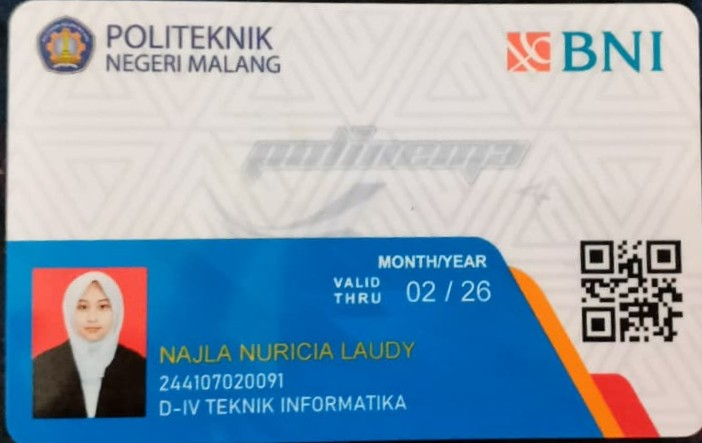

In [4]:
cv2_imshow(img)

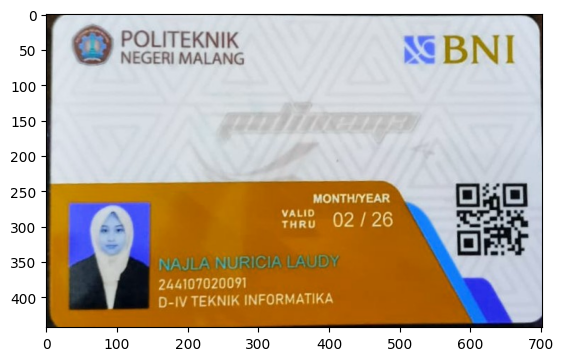

In [8]:
plt.imshow(img1)

In [9]:
#Cetak nilai 1 pixel yang sama

pixel = img[400,50]
pixel1 = img1[400,50]

print(pixel)
print(pixel1)

[32 44 50]
[32 44 50]


### Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32. Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.

Gambar nya sama saja namun untuk memori nya jelas berbeda. karena 16 dan 32. int32 membutuhkan 2x lipat nbytes

In [14]:

import numpy as np

canvas16 = np.zeros(shape=(530,530,3), dtype=np.int16)
canvas32 = np.zeros(shape=(530,530,3), dtype=np.int32)

print(canvas16.dtype)
print(canvas16.min())
print(canvas16.max())
print(canvas16.nbytes)
print('--------------')
print(canvas32.dtype)
print(canvas32.min())
print(canvas32.max())
print(canvas32.nbytes)


int16
0
0
1685400
--------------
int32
0
0
3370800


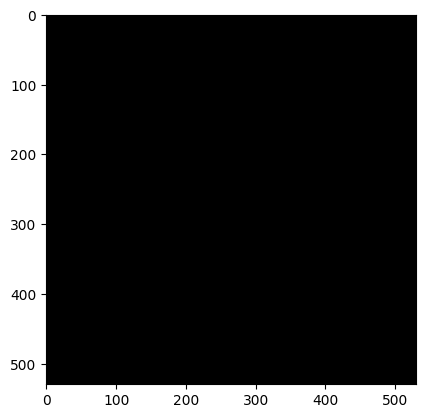

In [15]:
plt.imshow(canvas16)

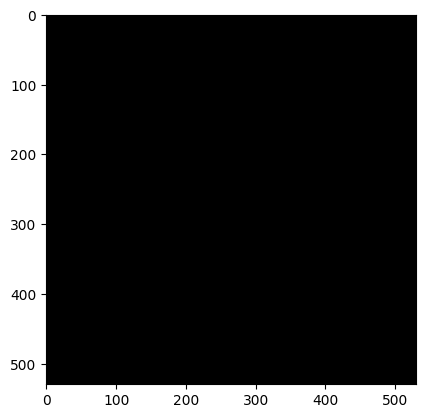

In [16]:
plt.imshow(canvas32)

### Apa kegunaan baris from google.colab.patches import cv2_imshow, dan mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?

Baris tersebut mengimpor fungsi cv2_imshow() yang disediakan khusus oleh Google Colab untuk menampilkan citra OpenCV langsung pada output notebook.

tidak bisa karena fungsi tersebut membutuhkan jendela tampilan langsung dari komputer, sedangkan Google Colab berjalan melalui browser. Oleh karena itu, digunakan cv2_imshow() agar gambar bisa ditampilkan langsung di dalam notebook.

### Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan visual saja.

sama nilai nya

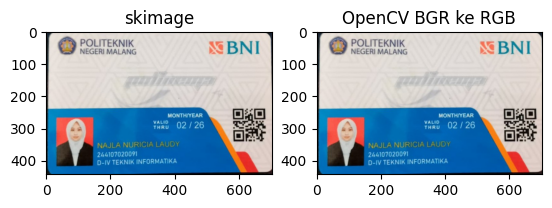

In [23]:
from skimage import io

img2 = io.imread('Ktm1b.jpeg')

img_cv = cv2.imread('Ktm1b.jpeg')
img3 = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

plt.subplot(1, 2, 1)
plt.imshow(img2)
plt.title("skimage")

plt.subplot(1, 2, 2)
plt.imshow(img3)
plt.title("OpenCV BGR ke RGB")

plt.show()


In [26]:
x = 450
y = 350

print("piksel:", (x, y))
print("skimage RGB ", img2[y, x])
print("OpenCV BGR ", img_cv[y, x])
print("OpenCV setelah RGB", img3[y, x])

piksel: (450, 350)
skimage RGB  [  1  96 178]
OpenCV BGR  [178  96   1]
OpenCV setelah RGB [  1  96 178]


### Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra dan mengubah ukuran tampilan.

Mengubah figsize tidak mengubah ukuran gambar sehingga nilai img.shape sebelum dan sesudah ditampilkan tetap sama.

figsize hanya mengatur ukuran tampilan figure Matplotlib, bukan jumlah piksel pada citra.

# TUGAS PRAKTIKUM - Penerapan

### Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau- Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya berdampingan dalam satu figure yang diberi judul.

<function matplotlib.pyplot.show(close=None, block=None)>

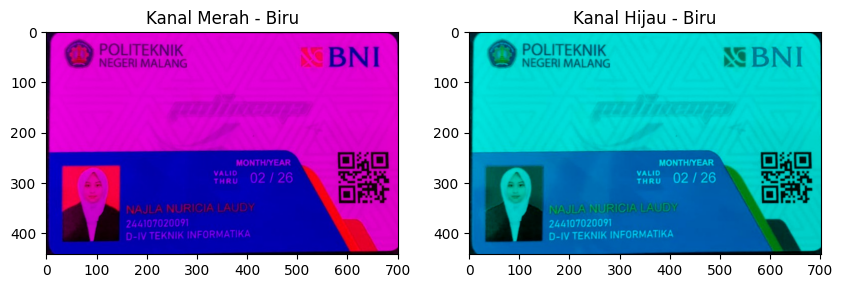

In [30]:
img4 = cv2.imread('Ktm1b.jpeg')

merah_biru = img4.copy()
merah_biru[:, :, 1] = 0

hijau_biru = img4.copy()
hijau_biru[:, :, 2] = 0

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(merah_biru, cv2.COLOR_BGR2RGB))
plt.title('Kanal Merah - Biru')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(hijau_biru, cv2.COLOR_BGR2RGB))
plt.title('Kanal Hijau - Biru')

plt.show

### Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi label.

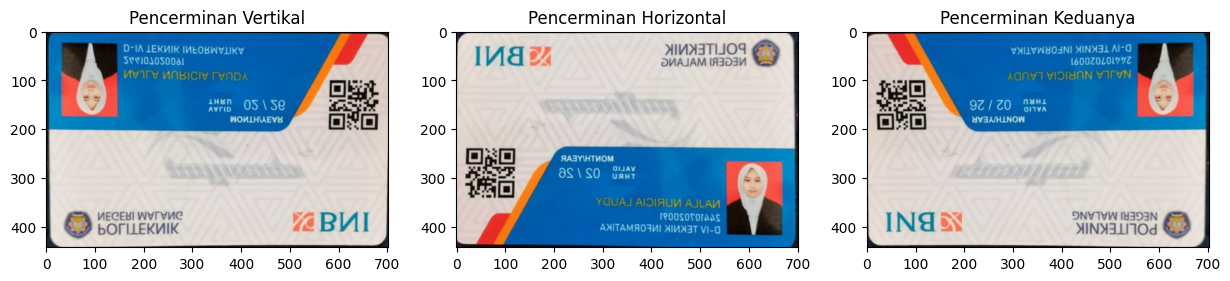

In [31]:
vertikal = cv2.flip(img4, 0)
horizontal = cv2.flip(img4, 1)
keduanya = cv2.flip(img4, -1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(vertikal, cv2.COLOR_BGR2RGB))
plt.title('Pencerminan Vertikal')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(horizontal, cv2.COLOR_BGR2RGB))
plt.title('Pencerminan Horizontal')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(keduanya, cv2.COLOR_BGR2RGB))
plt.title('Pencerminan Keduanya')

plt.show()

### Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah /badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda tentukan sendiri.

In [32]:
from google.colab import files
uploaded = files.upload()

Saving kegiatan.jpg to kegiatan.jpg


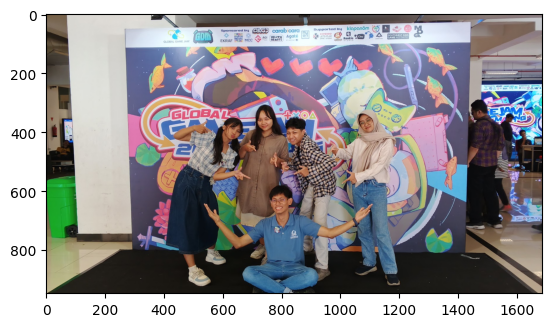

In [47]:
img5=cv2.imread('kegiatan.jpg')

img6 = plt.imshow(cv2.cvtColor(img5, cv2.COLOR_BGR2RGB))

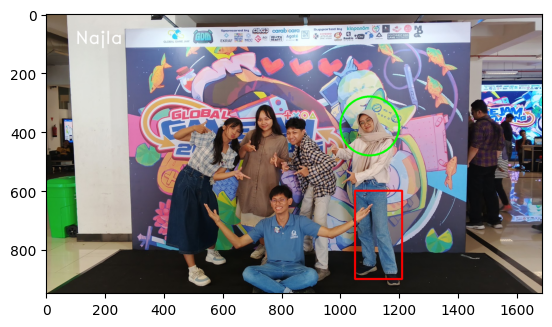

In [55]:
cv2.rectangle(
    img5,
    pt1=(1050, 900),
    pt2=(1210, 600),
    color=(0, 0, 255),
    thickness=5
)

cv2.circle(
    img5,
    center=(1100,380),
    radius=100,color=(0,255,0),
    thickness=5
)

font = cv2.FONT_HERSHEY_DUPLEX

cv2.putText(
    img5,
    text='Najla',
    org=(100, 100),
    fontFace=font,
    fontScale=2,
    color=(255, 255, 255),
    thickness=2,
    lineType=cv2.LINE_AA
)

plt.imshow(cv2.cvtColor(img5, cv2.COLOR_BGR2RGB))
plt.show()

# TUGAS PRAKTIKUM - Analisa

### Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya?Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan kesimpulan Anda.

Berapa persen piksel pada citra `Ktm1b.jpeg` yang memiliki nilai kanal biru lebih dari 100 jika dibandingkan dengan pixel biru tidak 0?


90.19634324374731


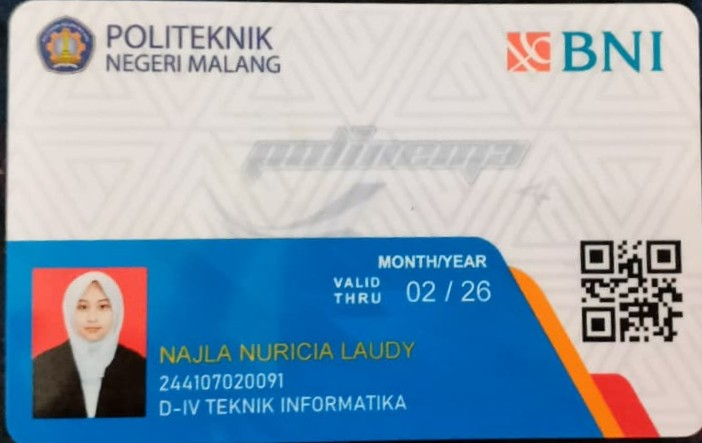

In [59]:
blue = img[:, :, 0]

total = blue.size

Blue_greater_100 = np.sum(blue > 100)

persentase = (Blue_greater_100 / total) * 100

print(persentase)

cv2_imshow(img)


# TUGAS PRAKTIKUM - Aplikasi

### Studi kasus 1 : Panitia sebuah kegiatan perlu membubuhkan label identitas pada ratusan foto dokumentasi. Foto berasal dari beberapa kamera dan ponsel, sehingga ukurannya bermacam-macam. Label harus terlihat seimbang pada semua foto tanpa disetel satu per satu. Fungsi yang sama dikenakan pada dua citra berbeda ukuran. Tinggi bar dan ukuran huruf ikut menyesuaikan, sehingga proporsinya tetap sama.

In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
folder = '/content/drive/MyDrive/coolyeah /PCVK/pcvk_raw'

In [62]:
import os

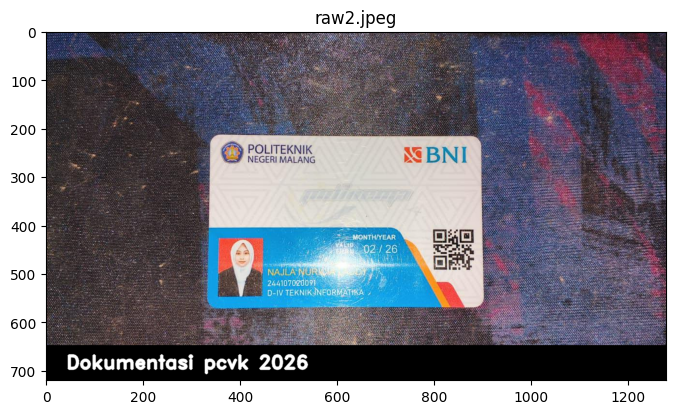

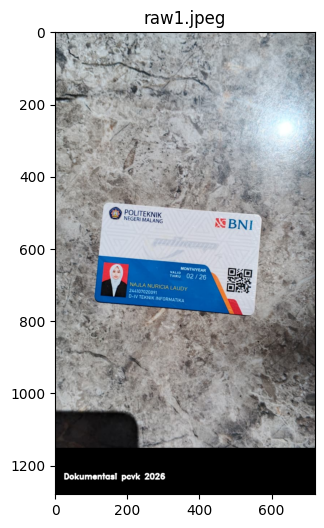

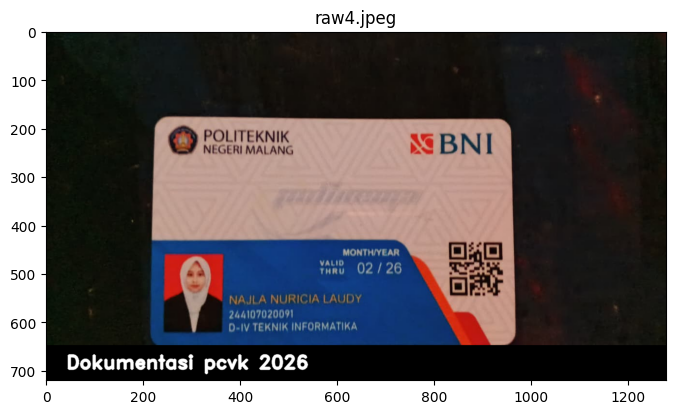

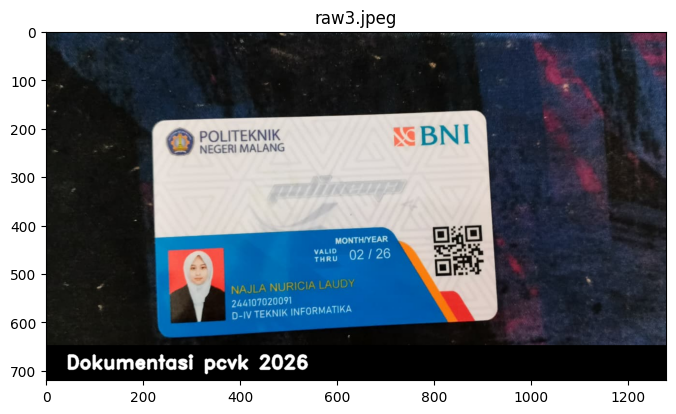

In [66]:

def label(img, nama):
    hasil = img.copy()

    tinggi = img.shape[0]
    lebar = img.shape[1]

    tinggi_label = tinggi // 10
    font_scale = lebar / 1000
    thickness = max(1, lebar // 300)

    cv2.rectangle(
        hasil,
        (0, tinggi - tinggi_label),
        (lebar, tinggi),
        (0, 0, 0),
        -1
    )


    x = lebar // 30
    y = tinggi - tinggi_label // 3

    cv2.putText(
        hasil,
        nama,
        (x, y),
        cv2.FONT_HERSHEY_DUPLEX,
        font_scale,
        (255, 255, 255),
        thickness,
        cv2.LINE_AA
    )

    return hasil


for nama_file in os.listdir(folder):

    path = os.path.join(folder, nama_file)

    img = cv2.imread(path)

    if img is None:
        continue

    hasil = label(img, 'Dokumentasi pcvk 2026')

    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB))
    plt.title(nama_file)
    plt.show()

### Marketplace seperti Tokopedia dan Shopee menampilkan foto produk dalam bingkai persegi 1:1. Foto penjual yang berukuran potrait atau lanskap akan terpotong atau terlihat tidak proporsional bila diunggah begitu saja. Bangun program yang mengubah foto berukuran apa pun menjadi thumbnail persegi tanpa mengubah rasio aslinya, dengan sisa ruang diisi kanvas berwarna. Dalam hal ini, rasio asli tetap terjaga, citra terpasang tepat di tengah kanvas,tambahkan logo nama toko berukuran proporsional pada gambar.

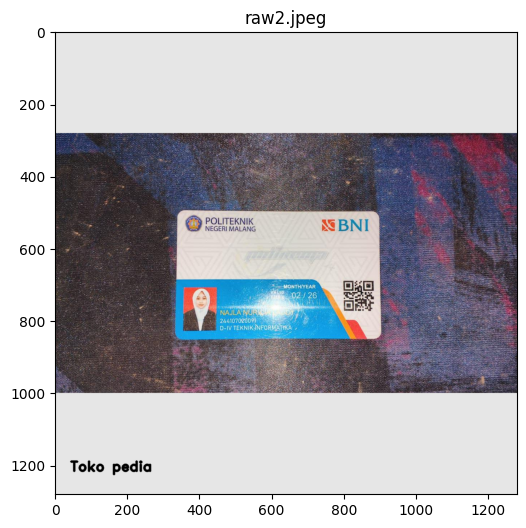

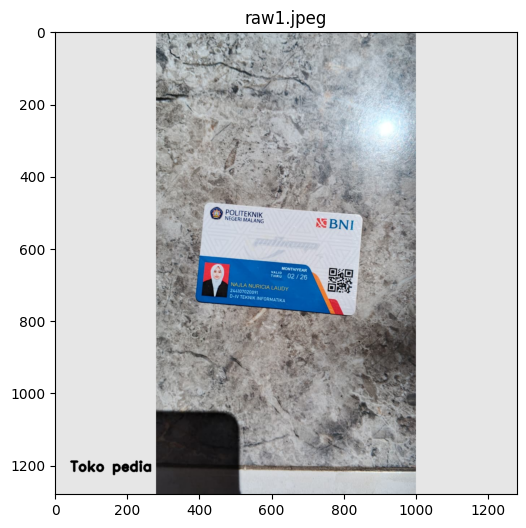

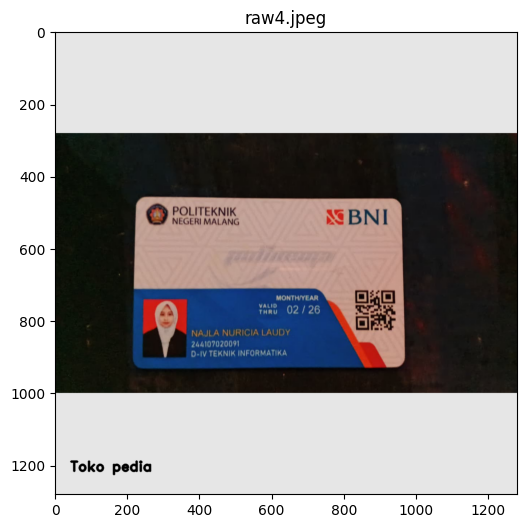

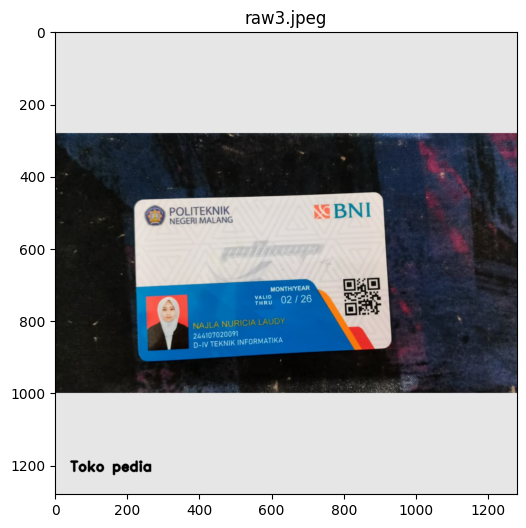

In [67]:
for nama_file in os.listdir(folder):

    path = os.path.join(folder, nama_file)
    img = cv2.imread(path)

    if img is None:
        continue

    tinggi = img.shape[0]
    lebar = img.shape[1]

    sisi = max(tinggi, lebar)

    kanvas = np.zeros((sisi, sisi, 3), dtype=np.uint8)
    kanvas[:, :] = (230, 230, 230)

    x = (sisi - lebar) // 2
    y = (sisi - tinggi) // 2

    kanvas[
        y:y + tinggi,
        x:x + lebar
    ] = img

    font_scale = max(0.5, sisi / 1000)
    thickness = max(1, sisi // 300)

    x_teks = sisi // 30
    y_teks = sisi - sisi // 20

    cv2.putText(
        kanvas,
        'Toko pedia',
        (x_teks, y_teks),
        cv2.FONT_HERSHEY_DUPLEX,
        font_scale,
        (0, 0, 0),
        thickness,
        cv2.LINE_AA
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(kanvas, cv2.COLOR_BGR2RGB))
    plt.title(nama_file)
    plt.show()